In [8]:
from datetime import datetime
name = "Riya Bablu Gupta"
current_time = datetime.now()
print(f"Name: {name}")
print("Current Date & Time:", current_time.strftime("%Y-%m-%d %H:%M:%S"))

Name: Riya Bablu Gupta
Current Date & Time: 2026-02-20 21:10:13


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# plt.style.use('fivethirtyeight')
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("Salary_Data.csv") #load data using pandas
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [3]:
df.shape

(30, 2)

In [4]:
print("Number of columns:", df.shape[1])

Number of columns: 2


In [5]:
print("Number of rows:", df.shape[0])

Number of rows: 30


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [7]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


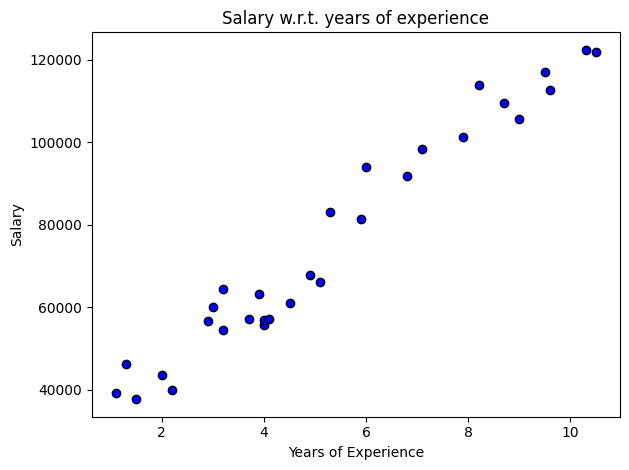

In [8]:
plt.scatter(x=df['YearsExperience'],y=df['Salary'] , color='blue' , edgecolor='black' , linewidth=1)
plt.title('Salary w.r.t. years of experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.tight_layout()
plt.show()

In [9]:
#take upper correlation matrix
matrix = np.triu(df.corr())
print(matrix)

[[1.         0.97824162]
 [0.         1.        ]]


In [10]:
X = df.iloc[:, :-1]
Y = df.iloc[:, -1]

In [11]:
X.head()

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2


In [12]:
Y.head()

0    39343.0
1    46205.0
2    37731.0
3    43525.0
4    39891.0
Name: Salary, dtype: float64

In [13]:
 X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 0)

In [14]:
import seaborn as sns

In [15]:
print("X_train", X_train.shape)
print("y_train", y_train.shape)



X_train (24, 1)
y_train (24,)


In [16]:
print("X_test", X_test.shape)
print("y_test", y_test.shape)

X_test (6, 1)
y_test (6,)


In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
regressor = LinearRegression()

In [19]:
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
y_pred = regressor.predict(X_test)

In [21]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [22]:
#check R square
R_Square = r2_score(y_pred, y_test)
print('R Square: ', R_Square)

#mean square error
MSE = mean_squared_error(y_pred, y_test)
print('Mean squared error : ', MSE)

#mean absolute error
MAE = mean_absolute_error(y_pred, y_test)
print('Mean absolute error : ', MAE)

R Square:  0.986482673117654
Mean squared error :  12823412.298126549
Mean absolute error :  2446.1723690465055


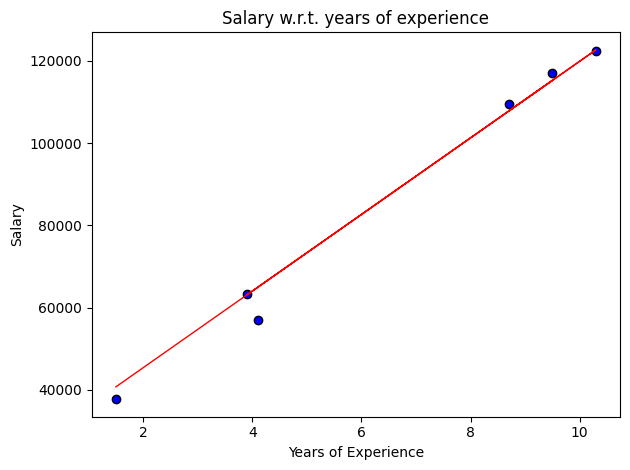

In [23]:
plt.scatter(X_test, y_test, color = 'blue', edgecolor = 'black', linewidth=1)
plt.plot(X_test, y_pred, color = 'red', linewidth = 1)

plt.title('Salary w.r.t. years of experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')

plt.tight_layout()
plt.show()

In [24]:
#What will be the salary if the years of experience is 19?
y_pred = regressor.predict([[19]])
print(y_pred)

[203719.02655848]


C:\Users\Riya_Gupta\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [25]:
col = ['Years of Experience', 'Salary']
pd.DataFrame([[19, '?']], columns = col)

,Years of Experience,Salary
0,19,?
